<h1 style="text-align: center;">Data-Driven Torque Surrogate for PMSM — PyTorch</h1>

El diseño de motores eléctricos es inherentemente un problema de **optimización multi-objetivo**: se busca maximizar el torque promedio mientras se minimiza el rizado de torque, y estos objetivos están en conflicto entre sí. Esto obliga a explorar un espacio de diseño enorme, iterando sobre muchos candidatos posibles.

### El cuello de botella: la simulación por elementos finitos (FEA)

El método estándar para evaluar cada diseño candidato es la simulación FEA (*Finite Element Analysis*), que es computacionalmente muy costosa. Cada evaluación requiere simular 21 posiciones angulares del rotor, y el proceso de optimización necesita miles de estas evaluaciones. Esto hace que el tiempo total de diseño sea prohibitivo.

### Las alternativas y sus limitaciones

Para aliviar este costo, se investigaron distintos enfoques:

- **Modelos analíticos físicos** (como el método de subdominios): son rápidos, pero hacen simplificaciones geométricas y asumen permeabilidad infinita del hierro, lo que los hace poco precisos para fenómenos altamente no lineales como el rizado de torque.
- **Redes neuronales puramente basadas en datos (NN)**: son muy poderosas para aprender funciones no lineales, pero requieren una gran cantidad de datos de entrenamiento (que a su vez se generan con FEA), y el entrenamiento es lento. Con pocos datos, su precisión se degrada considerablemente.

### La solución propuesta: PANN

La motivación central del paper es combinar lo mejor de ambos mundos mediante una **red neuronal asistida por física** (*Physics-Assisted Neural Network*, PANN). La idea clave es:

> El modelo analítico de subdominios genera una estimación inicial del torque, y esa estimación se usa como **entrada adicional** a la red neuronal, junto con los parámetros geométricos del motor.

Esto permite que la red neuronal aprenda a **corregir los errores del modelo físico** en lugar de aprender el problema desde cero. El resultado es que se necesita significativamente menos datos de entrenamiento para alcanzar la misma precisión que una NN pura.

### ¿Por qué importa especialmente para el rizado de torque?

El rizado de torque es particularmente difícil de predecir porque es un fenómeno muy no lineal y muy sensible a pequeñas variaciones en los parámetros de diseño. El modelo analítico solo tiene una precisión comparable a la NN en este caso, lo que es exactamente la condición en que PANN brinda el mayor beneficio: la física aporta suficiente información como para guiar el aprendizaje, pero no es suficientemente precisa por sí sola.

### Conclusión

La motivación es **reducir el costo de preparación de datos** (menos simulaciones FEA) sin sacrificar precisión, aprovechando que el conocimiento físico —aunque imperfecto— puede acelerar y mejorar el aprendizaje de la red neuronal.

# Modelo sustituto de torque basado en datos para PMSM — PyTorch

**Pipeline:** dataset FEMM (diseños LHS + barrido de torque) → MLP sustituto → optimización (GA)

- **Entradas (5 o 6):** parámetros de diseño `b`, `x`, `outer_radius`, `phase_current`, `torque` (analítico). Cuando `USE_COGGING_INPUT=True`, se agrega el torque de cogging analítico `cogging_zhu` (método energético de Zhu-Howe) como 6.ª entrada.
- **Salidas:** subconjunto configurable de armónicos de torque. Configurar `SELECTED_HARMONICS` en la celda de carga de datos para elegir qué índices de armónicos aprender (ej. `[0, 2, 6]`). La codificación de fase se controla con `USE_SINCOS_ENCODING`:
  - `True` (por defecto): fases codificadas como pares `sin(θ)` / `cos(θ)` para evitar discontinuidades angulares. Dimensión de salida = `3 * len(SELECTED_HARMONICS)` (1 amplitud + 2 componentes de fase por armónico)
  - `False`: ángulos de fase crudos en grados. Dimensión de salida = `2 * len(SELECTED_HARMONICS)` (1 amplitud + 1 fase por armónico)

El modelo sustituto aprende a mapear parámetros de geometría/excitación del motor directamente a la
descomposición de Fourier de la forma de onda de torque, evitando FEMM en tiempo de inferencia.

> Fecha: 2026-02-13

In [1]:

# !pip install torch numpy pandas matplotlib scikit-learn tqdm

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 1) Data sources

Two CSV files produced by the dataset generation pipeline:

**`dataset/designs.csv`** — one row per motor design (LHS sampling):
- Input features: `b`, `x`, `outer_radius`, `phase_current`, `torque` (analytical torque from motor model)
- When `USE_COGGING_INPUT=True`: an additional `cogging_zhu` column is computed on-the-fly via `cogging_torque_from_row()` from `femm_utils.py` (Zhu-Howe energy method)
- Filter: `error_code == 0` and non-empty `fem_file`

**`dataset/torque_results.csv`** — one row per simulated model (from `run_sweep.py`):
- Contains: `h0_amp..h9_amp` (harmonic amplitudes), `h0_phase..h9_phase` (harmonic phases). Only the subset defined by `SELECTED_HARMONICS` is used as targets
- Also contains: `sample_id`, `iq_angle_optimo`, `iq`, `torque_mean`

Both files are joined on `sample_id`.


In [2]:

# ---- paths ----
DATASET_DIR = 'dataset'
MODEL_OUTPUT_DIR = 'model'

DESIGNS_CSV = os.path.join(DATASET_DIR, 'designs.csv')
TORQUE_CSV  = os.path.join(DATASET_DIR, 'torque_results.csv')

INPUT_COLS  = ['b', 'x', 'outer_radius', 'phase_current', 'torque']

SELECTED_HARMONICS = [0, 2, 6]
USE_SINCOS_ENCODING = False
USE_COGGING_INPUT = True

if USE_COGGING_INPUT:
    from femm_utils import cogging_torque_from_row as _cogging_from_row
    INPUT_COLS = INPUT_COLS + ['cogging_zhu']

N_HARMONICS = len(SELECTED_HARMONICS)
AMP_COLS    = [f'h{i}_amp'   for i in SELECTED_HARMONICS]
PHASE_COLS  = [f'h{i}_phase' for i in SELECTED_HARMONICS]

if USE_SINCOS_ENCODING:
    PHASE_SIN_COLS = [f'h{i}_phase_sin' for i in SELECTED_HARMONICS]
    PHASE_COS_COLS = [f'h{i}_phase_cos' for i in SELECTED_HARMONICS]
    TARGET_COLS = AMP_COLS + PHASE_SIN_COLS + PHASE_COS_COLS
else:
    TARGET_COLS = AMP_COLS + PHASE_COLS


def load_dataset(designs_csv: str, torque_csv: str,
                 test_size: float = 0.2, seed: int = 42):
    """
    Load and merge both CSVs, filter invalid rows, and split train/val.
    If USE_COGGING_INPUT is True, the cogging_zhu column is computed from geometry.
    If USE_SINCOS_ENCODING is True, phase angles are converted to sin/cos pairs.
    
    Returns
    -------
    X_train, X_val : np.ndarray  (N, 5)
    Y_train, Y_val : np.ndarray  (N, len(TARGET_COLS))
    df              : merged DataFrame (for later inspection)
    """
    # --- designs ---
    df_des = pd.read_csv(designs_csv)
    df_des = df_des[df_des['error_code'] == 0]
    df_des = df_des[df_des['fem_file'].notna() & (df_des['fem_file'].str.strip() != '')]

    if USE_COGGING_INPUT:
        df_des['cogging_zhu'] = df_des.apply(
            lambda r: _cogging_from_row(r), axis=1)

    df_des = df_des[['sample_id'] + INPUT_COLS]

    # --- torque results ---
    df_torque = pd.read_csv(torque_csv)
    df_torque = df_torque[['sample_id'] + AMP_COLS + PHASE_COLS]

    if USE_SINCOS_ENCODING:
        for phase_col, sin_col, cos_col in zip(PHASE_COLS, PHASE_SIN_COLS, PHASE_COS_COLS):
            rad = np.deg2rad(df_torque[phase_col].values)
            df_torque[sin_col] = np.sin(rad)
            df_torque[cos_col] = np.cos(rad)

    # --- inner join ---
    df = pd.merge(df_des, df_torque, on='sample_id', how='inner')
    print(f'Loaded {len(df)} valid samples (merged)')

    X = df[INPUT_COLS].values.astype(np.float32)
    Y = df[TARGET_COLS].values.astype(np.float32)

    X_train, X_val, Y_train, Y_val = train_test_split(
        X, Y, test_size=test_size, random_state=seed
    )
    print(f'  Train: {len(X_train)},  Val: {len(X_val)}')
    return X_train, X_val, Y_train, Y_val, df


X_train, X_val, Y_train, Y_val, df_all = load_dataset(DESIGNS_CSV, TORQUE_CSV)
df_all.head()


Loaded 46 valid samples (merged)
  Train: 36,  Val: 10


,sample_id,b,x,outer_radius,phase_current,torque,cogging_zhu,h0_amp,h2_amp,h6_amp,h0_phase,h2_phase,h6_phase
0,1,0.675501,0.605928,0.055770,290.810818,4.194764,0.077135,3.491381,0.041992,0.562706,0.0,-150.2989,96.8783
1,2,0.715627,0.433341,0.067629,313.317131,5.795980,0.069333,5.981846,0.006932,0.674834,0.0,-98.9917,-2.6727
2,3,0.649032,0.442498,0.065046,336.156569,5.485095,0.054482,5.694285,0.012075,0.629532,0.0,-95.5968,-4.4433
3,4,0.588513,0.389404,0.040088,98.755882,0.896824,0.070211,0.729691,0.000542,0.147474,0.0,-142.4752,41.8426
4,5,0.737968,0.582241,0.086268,674.508183,16.456582,0.050340,16.961814,0.228194,0.358991,0.0,-108.7376,53.5570


## 2) Normalization

Inputs and outputs are scaled to `[-1, 1]` independently using min-max normalization.
This helps the MLP converge faster and treats all features equally.


In [3]:

class Normalizer:
    """Min-max scaler to [-1, 1]."""
    def __init__(self, lo: np.ndarray, hi: np.ndarray, eps=1e-12):
        self.lo = lo.astype(np.float64)
        self.hi = hi.astype(np.float64)
        self.eps = eps
    def encode(self, x: np.ndarray) -> np.ndarray:
        return (2.0 * (x - self.lo) / (self.hi - self.lo + self.eps) - 1.0).astype(np.float32)
    def decode(self, z: np.ndarray) -> np.ndarray:
        return ((z + 1.0) * 0.5 * (self.hi - self.lo) + self.lo).astype(np.float32)
    @classmethod
    def from_data(cls, data: np.ndarray):
        return cls(data.min(axis=0), data.max(axis=0))


# Build normalizers from TRAINING data only
norm_X = Normalizer.from_data(X_train)
norm_Y = Normalizer.from_data(Y_train)

Xn_train = norm_X.encode(X_train)
Xn_val   = norm_X.encode(X_val)
Yn_train = norm_Y.encode(Y_train)
Yn_val   = norm_Y.encode(Y_val)

print(f'Xn_train range: [{Xn_train.min():.3f}, {Xn_train.max():.3f}]')
print(f'Yn_train range: [{Yn_train.min():.3f}, {Yn_train.max():.3f}]')


Xn_train range: [-1.000, 1.000]
Yn_train range: [-1.000, 1.000]


## 3) MLP model

A simple fully-connected network: `len(INPUT_COLS)` inputs (5 base, or 6 with `USE_COGGING_INPUT=True`) → hidden layers → `len(TARGET_COLS)` outputs. With `USE_SINCOS_ENCODING=True` this is 3x N_HARMONICS (amp + phase_sin + phase_cos); with `False` it is 2x N_HARMONICS (amp + phase_deg).

Architecture is configurable via `width` and `depth` parameters.
Default: 6 hidden layers of 128 neurons with Tanh activation.


In [4]:

class MLP(nn.Module):
    def __init__(self, in_dim=len(INPUT_COLS), out_dim=len(TARGET_COLS), width=128, depth=6,
                 act=nn.Tanh, dropout=0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), act()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = width
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
        # Xavier init
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


## 4) Training

- **Loss:** MSE on all 20 normalized outputs (amplitudes + phases)
- **Optimizer:** Adam with configurable learning rate
- **Scheduler:** ReduceLROnPlateau watching validation loss
- **Early history:** logged every epoch for train and val


In [5]:

def train_surrogate(
    Xn_train, Yn_train, Xn_val, Yn_val,
    in_dim=5, out_dim=20,
    width=128, depth=6,
    epochs=2000, lr=1e-3, batch_size=32,
    dropout=0.0, weight_decay=0.0,
    seed=42
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = MLP(in_dim=in_dim, out_dim=out_dim, width=width, depth=depth,
                dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=200
    )
    criterion = nn.MSELoss()

    # DataLoaders
    ds_train = TensorDataset(
        torch.tensor(Xn_train, device=device),
        torch.tensor(Yn_train, device=device)
    )
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(Xn_val, device=device)
    Y_val_t = torch.tensor(Yn_val, device=device)

    hist = []

    for ep in tqdm(range(1, epochs + 1), desc='Training'):
        # --- train ---
        model.train()
        batch_losses = []
        for Xb, Yb in dl_train:
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, Yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        # --- val ---
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, Y_val_t).item()

        scheduler.step(val_loss)

        if ep == 1 or ep % 50 == 0 or ep == epochs:
            hist.append({
                'epoch': ep,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'lr': optimizer.param_groups[0]['lr'],
            })

    return model, pd.DataFrame(hist)


## 5) Run training


In [6]:

model, hist = train_surrogate(
    Xn_train, Yn_train, Xn_val, Yn_val,
    in_dim=len(INPUT_COLS),
    out_dim=len(TARGET_COLS),
    width=32,
    depth=3,
    epochs=5000,
    lr=1e-3,
    batch_size=16,
    dropout=0.1,
    weight_decay=1e-4,
    seed=42
)

hist.tail()


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

,epoch,train_loss,val_loss,lr
96,4800,0.091948,0.100396,1.525879e-08
97,4850,0.063717,0.100394,1.525879e-08
98,4900,0.069795,0.100395,1.525879e-08
99,4950,0.089550,0.100394,1.525879e-08
100,5000,0.067764,0.100394,1.525879e-08


In [11]:
CKPT_PATH = os.path.join(MODEL_OUTPUT_DIR, 'surrogate_model_phase.pt')
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

ckpt = {
    'model_state': model.state_dict(),
    'arch': {'in_dim': len(INPUT_COLS), 'out_dim': len(TARGET_COLS),
             'width': 32, 'depth': 3, 'dropout': 0.1},
    'norm_X': {'lo': norm_X.lo, 'hi': norm_X.hi},
    'norm_Y': {'lo': norm_Y.lo, 'hi': norm_Y.hi},
    'selected_harmonics': SELECTED_HARMONICS,
    'history': hist.to_dict(),
}
torch.save(ckpt, CKPT_PATH)
print(f"Checkpoint saved to {CKPT_PATH}")

Checkpoint saved to model\surrogate_model_phase.pt


## 5b) Load saved model (optional)

If you already trained and saved a checkpoint, you can **skip cells 9–12** (training + save) and run this cell instead.  
Prerequisites: cells 1 (imports), 3 (data + config), 5 (normalizers), 7 (MLP class).

In [ ]:
CKPT_PATH = os.path.join(MODEL_OUTPUT_DIR, 'surrogate_model.pt')

if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

    ckpt_harmonics = ckpt.get('selected_harmonics', [])
    ckpt_out_dim = ckpt['arch'].get('out_dim', 0)
    expected_out_dim = len(TARGET_COLS)
    if ckpt_harmonics != SELECTED_HARMONICS or ckpt_out_dim != expected_out_dim:
        raise RuntimeError(
            f"Checkpoint incompatible with current config.\n"
            f"  Checkpoint: harmonics={ckpt_harmonics}, out_dim={ckpt_out_dim}\n"
            f"  Current:    harmonics={SELECTED_HARMONICS}, out_dim={expected_out_dim}\n"
            f"Delete {CKPT_PATH} and retrain the model."
        )

    model = MLP(**ckpt['arch']).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    norm_X = Normalizer(np.array(ckpt['norm_X']['lo']),
                        np.array(ckpt['norm_X']['hi']))
    norm_Y = Normalizer(np.array(ckpt['norm_Y']['lo']),
                        np.array(ckpt['norm_Y']['hi']))

    hist = pd.DataFrame(ckpt['history'])

    print(f"Checkpoint loaded from {CKPT_PATH}")
    print(f"  Architecture: {ckpt['arch']}")
    print(f"  Harmonics:    {ckpt_harmonics}")
else:
    if 'model' not in dir() or model is None:
        raise RuntimeError(f"No checkpoint at {CKPT_PATH} and no trained model in memory — run training first.")

Checkpoint loaded from dataset\surrogate_model.pt
  Architecture: {'in_dim': 5, 'out_dim': 9, 'width': 32, 'depth': 3, 'dropout': 0.1}
  Harmonics:    [0, 2, 6]


## 6) Loss history


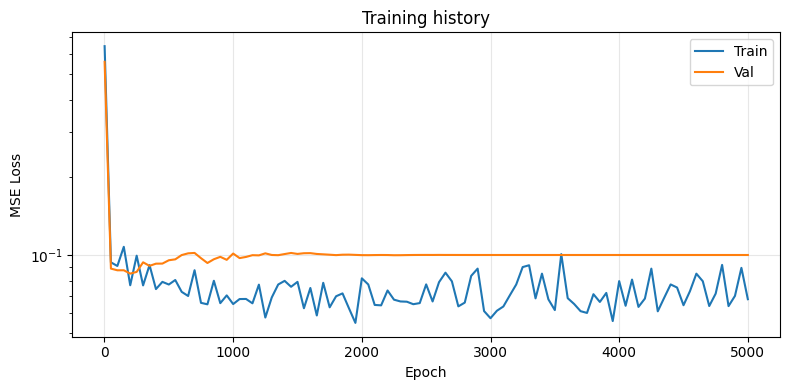

In [7]:

def plot_history(hist: pd.DataFrame):
    if hist is None or len(hist) == 0:
        print('Empty history.')
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hist['epoch'], hist['train_loss'], label='Train')
    ax.plot(hist['epoch'], hist['val_loss'],   label='Val')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_yscale('log')
    ax.legend()
    ax.set_title('Training history')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(hist)


## 6b) Diagnosis and improved training

**Observed issues in the baseline training:**

| Output | R² | Assessment |
|---|---|---|
| h0_amp | 0.97 | Good |
| h2_amp | 0.93 | Good |
| h6_amp | 0.10 | Poor |
| h0_phase | 1.00 | Trivial (always 0) |
| h2_phase | −8.44 | Catastrophic |
| h6_phase | 0.33 | Poor |

The train/val loss gap is small (~0.07 vs ~0.086), which indicates **underfitting** rather than overfitting — the network lacks capacity to capture the complex non-linear relationships, especially for the harmonic phases.

Additionally, the ReduceLROnPlateau scheduler drove the learning rate down to ~1.5e-8 long before epoch 5000, meaning thousands of epochs were wasted.

**Improvements applied below:**

1. **Early stopping** — training halts when `val_loss` has not improved for `es_patience` consecutive epochs. The best model weights are restored automatically.
2. **Larger network** — `width=64, depth=4` to increase representational capacity.
3. **Cosine-annealing LR** — smoother schedule with warm restarts, avoids the aggressive LR decay that stalls training.
4. **Larger batch size** — `batch_size=32` for more stable gradients.
5. **Increased regularization** — `dropout=0.15`, `weight_decay=5e-4` to counterbalance the larger model.

In [8]:
def train_surrogate_v2(
    Xn_train, Yn_train, Xn_val, Yn_val,
    in_dim=5, out_dim=20,
    width=64, depth=4,
    epochs=10000, lr=1e-3, batch_size=32,
    dropout=0.15, weight_decay=5e-4,
    es_patience=500,
    seed=42
):
    """
    Improved training loop with early stopping and cosine-annealing LR.

    Parameters
    ----------
    es_patience : int
        Stop training if val_loss has not improved for this many epochs.
        The best model weights are restored at the end.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = MLP(in_dim=in_dim, out_dim=out_dim, width=width, depth=depth,
                dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=500, T_mult=2, eta_min=1e-6
    )
    criterion = nn.MSELoss()

    ds_train = TensorDataset(
        torch.tensor(Xn_train, device=device),
        torch.tensor(Yn_train, device=device)
    )
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(Xn_val, device=device)
    Y_val_t = torch.tensor(Yn_val, device=device)

    hist = []
    best_val = float('inf')
    best_state = None
    no_improve = 0

    for ep in tqdm(range(1, epochs + 1), desc='Training v2'):
        model.train()
        batch_losses = []
        for Xb, Yb in dl_train:
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, Yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, Y_val_t).item()

        scheduler.step(ep)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if ep == 1 or ep % 50 == 0 or ep == epochs or no_improve == es_patience:
            hist.append({
                'epoch': ep,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'lr': optimizer.param_groups[0]['lr'],
            })

        if no_improve >= es_patience:
            print(f"\nEarly stopping at epoch {ep} (best val_loss={best_val:.6f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(hist)

In [9]:
model, hist = train_surrogate_v2(
    Xn_train, Yn_train, Xn_val, Yn_val,
    in_dim=len(INPUT_COLS),
    out_dim=len(TARGET_COLS),
    width=64,
    depth=4,
    epochs=10000,
    lr=1e-3,
    batch_size=32,
    dropout=0.15,
    weight_decay=5e-4,
    es_patience=500,
    seed=42
)

hist.tail()

Training v2:   0%|          | 0/10000 [00:00<?, ?it/s]


Early stopping at epoch 599 (best val_loss=0.064148)


,epoch,train_loss,val_loss,lr
8,400,0.071197,0.081437,0.000096
9,450,0.072436,0.083967,0.000025
10,500,0.103910,0.084414,0.001000
11,550,0.104710,0.113265,0.000994
12,599,0.074751,0.076302,0.000976


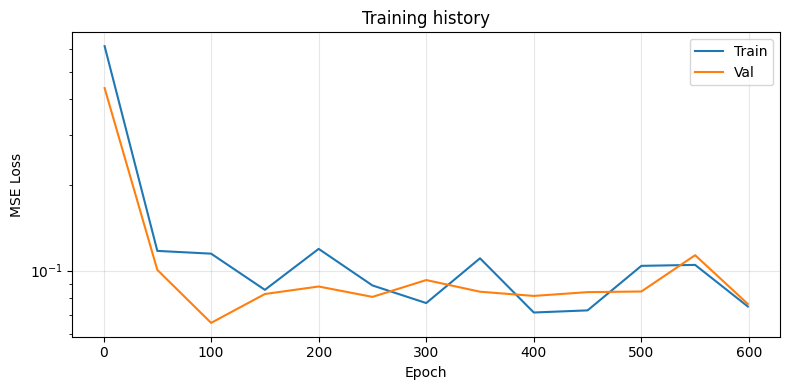

R² per output (v2):
  output        R2
  h0_amp  0.986199
  h2_amp  0.839395
  h6_amp -0.225039
h0_phase  1.000000
h2_phase -1.412350
h6_phase  0.252555

Overall mean R²: 0.2401


In [11]:
plot_history(hist)

Y_pred_v2 = evaluate_model(model, Xn_val, Y_val, norm_Y, TARGET_COLS)

from sklearn.metrics import r2_score
r2_v2 = [r2_score(Y_val[:, i], Y_pred_v2[:, i]) for i in range(Y_val.shape[1])]
r2_df_v2 = pd.DataFrame({'output': TARGET_COLS, 'R2': r2_v2})
print('R\u00b2 per output (v2):')
print(r2_df_v2.to_string(index=False))
print(f'\nOverall mean R\u00b2: {np.mean(r2_v2):.4f}')

## 7) Evaluation

Scatter plots of predicted vs. actual values for:
- Mean torque (`h0_amp`)
- Selected harmonics (`h1_amp`, `h2_amp`)
- Overall R² score


R² per output:
  output        R2
  h0_amp  0.986199
  h2_amp  0.839395
  h6_amp -0.225039
h0_phase  1.000000
h2_phase -1.412350
h6_phase  0.252555

Overall mean R²: 0.2401


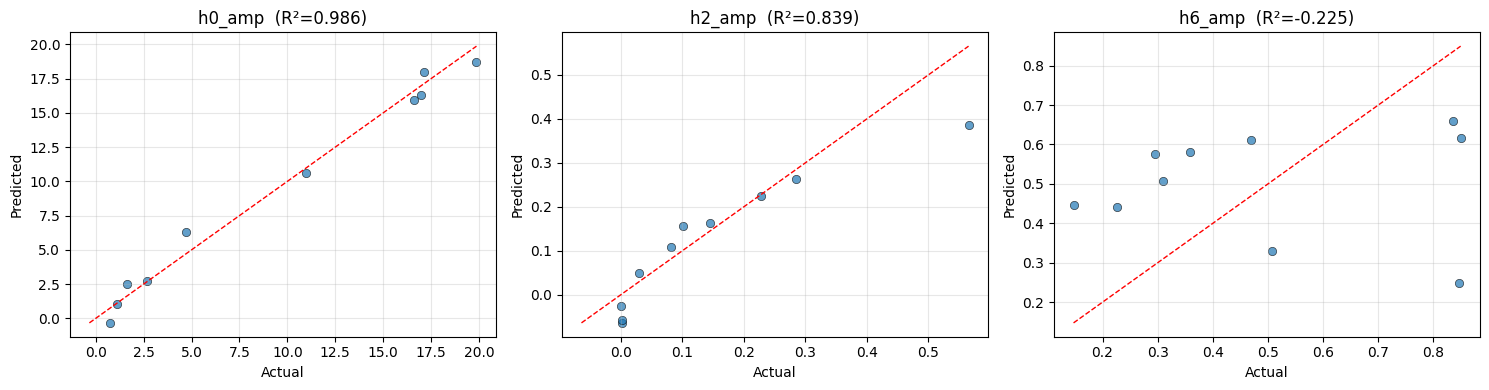

In [10]:

def evaluate_model(model, Xn_val, Y_val, norm_Y, target_cols):
    """Evaluate on validation set, return predictions in original scale."""
    model.eval()
    with torch.no_grad():
        Yn_pred = model(torch.tensor(Xn_val, device=device)).cpu().numpy()
    Y_pred = norm_Y.decode(Yn_pred)
    return Y_pred


Y_pred = evaluate_model(model, Xn_val, Y_val, norm_Y, TARGET_COLS)

# --- R^2 per output ---
from sklearn.metrics import r2_score
r2_per_output = [r2_score(Y_val[:, i], Y_pred[:, i]) for i in range(Y_val.shape[1])]
r2_df = pd.DataFrame({'output': TARGET_COLS, 'R2': r2_per_output})
print('R\u00b2 per output:')
print(r2_df.to_string(index=False))
print(f'\nOverall mean R\u00b2: {np.mean(r2_per_output):.4f}')

# --- Scatter plots for key harmonics ---
n_scatter = min(3, len(AMP_COLS))
fig, axes = plt.subplots(1, n_scatter, figsize=(5 * n_scatter, 4))
if n_scatter == 1:
    axes = [axes]
plot_indices = list(range(n_scatter))
plot_names   = [AMP_COLS[i] for i in plot_indices]

for ax, idx, name in zip(axes, plot_indices, plot_names):
    y_true = Y_val[:, idx]
    y_hat  = Y_pred[:, idx]
    ax.scatter(y_true, y_hat, alpha=0.7, edgecolors='k', linewidths=0.5)
    lims = [min(y_true.min(), y_hat.min()), max(y_true.max(), y_hat.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}  (R\u00b2={r2_per_output[idx]:.3f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8) Surrogate callable for optimization

This function replaces FEMM at inference time.
Given design parameters, it returns the predicted torque harmonics.


In [12]:

def surrogate_predict(model, norm_X, norm_Y, **inputs) -> dict:
    """
    Predict torque harmonics for a single design point.
    Pass each INPUT_COLS column as a keyword argument, e.g.
        surrogate_predict(model, norm_X, norm_Y, b=0.65, x=0.5, ...)
    When USE_COGGING_INPUT is True, include cogging_zhu=<value>.
    Always returns h{i}_amp and h{i}_phase (degrees), regardless of
    USE_SINCOS_ENCODING (sin/cos outputs are converted back via arctan2).

    Returns
    -------
    dict with keys h{i}_amp, h{i}_phase (degrees) + torque_mean (if h0 selected)
    """
    model.eval()
    inp = np.array([[inputs[col] for col in INPUT_COLS]], dtype=np.float32)
    inp_n = norm_X.encode(inp)

    with torch.no_grad():
        out_n = model(torch.tensor(inp_n, device=device)).cpu().numpy()

    out = norm_Y.decode(out_n).flatten()

    raw = {col: float(val) for col, val in zip(TARGET_COLS, out)}

    result = {}
    for h in SELECTED_HARMONICS:
        result[f'h{h}_amp'] = raw[f'h{h}_amp']
        if USE_SINCOS_ENCODING:
            s = raw[f'h{h}_phase_sin']
            c = raw[f'h{h}_phase_cos']
            result[f'h{h}_phase'] = float(np.degrees(np.arctan2(s, c)))
        else:
            result[f'h{h}_phase'] = raw[f'h{h}_phase']

    if 'h0_amp' in result:
        result['torque_mean'] = result['h0_amp']
    return result


# --- Example usage ---
test_row = df_all.iloc[1]
pred = surrogate_predict(
    model, norm_X, norm_Y,
    **{col: float(test_row[col]) for col in INPUT_COLS}
)

print('Surrogate prediction for sample', int(test_row['sample_id']))
if 'torque_mean' in pred:
    print(f"  Mean torque (h0_amp): {pred['torque_mean']:.4f}")
for h in SELECTED_HARMONICS:
    print(f"  h{h}_amp = {pred[f'h{h}_amp']:.4f},  h{h}_phase = {pred[f'h{h}_phase']:.2f} deg")


Surrogate prediction for sample 2
  Mean torque (h0_amp): 6.1567
  h0_amp = 6.1567,  h0_phase = 0.00 deg
  h2_amp = -0.0091,  h2_phase = -117.86 deg
  h6_amp = 0.4956,  h6_phase = 39.88 deg


In [13]:
# --- Compare predicted vs dataset for all harmonics ---
sid = int(test_row['sample_id'])

rows = []
for h in SELECTED_HARMONICS:
    amp_actual   = float(test_row[f'h{h}_amp'])
    phase_actual = float(test_row[f'h{h}_phase'])  # original degrees from CSV
    rows.append({
        'Harmonic': f'h{h}',
        'Amp (dataset)':   amp_actual,
        'Amp (pred)':      pred[f'h{h}_amp'],
        'Amp error':       pred[f'h{h}_amp'] - amp_actual,
        'Phase (dataset)': phase_actual,
        'Phase (pred)':    pred[f'h{h}_phase'],
        'Phase error':     pred[f'h{h}_phase'] - phase_actual,
    })

df_cmp = pd.DataFrame(rows)
print(f'Sample {sid} — Predicted vs Dataset (selected harmonics: {SELECTED_HARMONICS})\n')
print(df_cmp.to_string(index=False, float_format='%.4f'))


Sample 2 — Predicted vs Dataset (selected harmonics: [0, 2, 6])

Harmonic  Amp (dataset)  Amp (pred)  Amp error  Phase (dataset)  Phase (pred)  Phase error
      h0         5.9818      6.1567     0.1749           0.0000        0.0000       0.0000
      h2         0.0069     -0.0091    -0.0161         -98.9917     -117.8624     -18.8707
      h6         0.6748      0.4956    -0.1793          -2.6727       39.8828      42.5555


Batch comparison — first 46 samples
      Column          R²           MAE
--------------------------------------
      h0_amp      0.9860      0.612295
      h2_amp      0.9005      0.037145
      h6_amp      0.1703      0.203601
    h0_phase      1.0000      0.000000
    h2_phase      0.1021     30.468208
    h6_phase      0.3554     37.698021


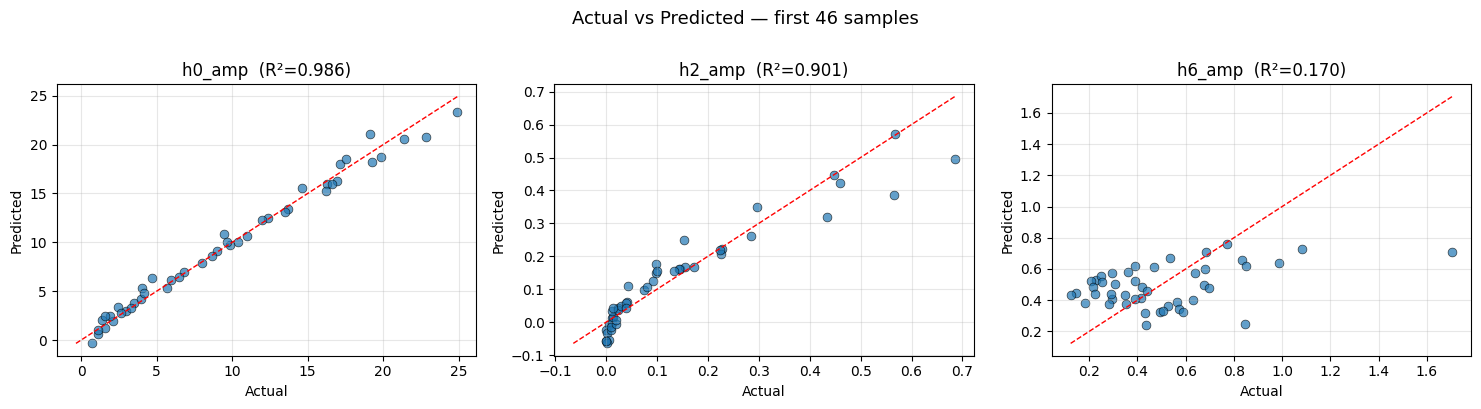

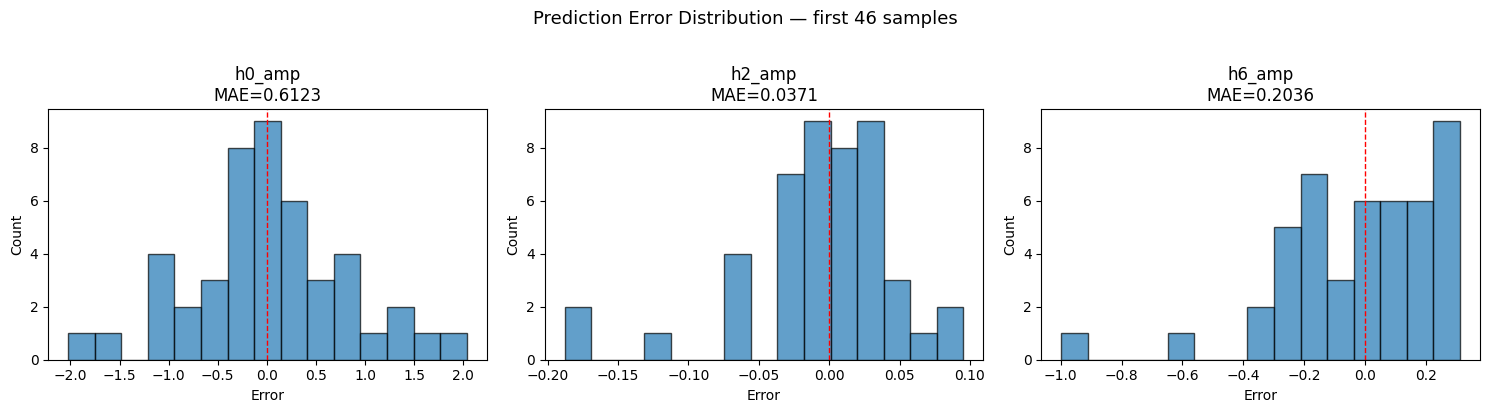

In [14]:
# --- Batch comparison: first N samples of the full dataset ---
N_COMPARE = min(50, len(df_all))

X_all = df_all[INPUT_COLS].values.astype(np.float32)
Y_all = df_all[TARGET_COLS].values.astype(np.float32)

Xn_all = norm_X.encode(X_all[:N_COMPARE])
model.eval()
with torch.no_grad():
    Yn_pred_all = model(torch.tensor(Xn_all, device=device)).cpu().numpy()
Y_pred_all = norm_Y.decode(Yn_pred_all)
Y_true_all = Y_all[:N_COMPARE]

# Per-output R² for this subset
from sklearn.metrics import r2_score, mean_absolute_error
r2_batch = {col: r2_score(Y_true_all[:, i], Y_pred_all[:, i])
            for i, col in enumerate(TARGET_COLS)}
mae_batch = {col: mean_absolute_error(Y_true_all[:, i], Y_pred_all[:, i])
             for i, col in enumerate(TARGET_COLS)}

print(f"Batch comparison — first {N_COMPARE} samples")
print(f"{'Column':>12}  {'R²':>10}  {'MAE':>12}")
print("-" * 38)
for col in TARGET_COLS:
    print(f"{col:>12}  {r2_batch[col]:>10.4f}  {mae_batch[col]:>12.6f}")

# --- Scatter plots: actual vs predicted per amplitude harmonic ---
n_amp = len(AMP_COLS)
n_cols_plot = min(n_amp, 4)
n_rows_plot = math.ceil(n_amp / n_cols_plot)
fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(5 * n_cols_plot, 4 * n_rows_plot), squeeze=False)
axes_flat = axes.flatten()

for i, col in enumerate(AMP_COLS):
    ax = axes_flat[i]
    y_true = Y_true_all[:, i]
    y_pred = Y_pred_all[:, i]
    ax.scatter(y_true, y_pred, alpha=0.7, edgecolors='k', linewidths=0.5, s=40)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{col}  (R²={r2_batch[col]:.3f})')
    ax.grid(True, alpha=0.3)

for j in range(n_amp, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f'Actual vs Predicted — first {N_COMPARE} samples', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Error distribution per amplitude harmonic ---
fig, axes = plt.subplots(1, n_amp, figsize=(5 * n_amp, 4), squeeze=False)
for i, col in enumerate(AMP_COLS):
    ax = axes[0, i]
    errors = Y_pred_all[:, i] - Y_true_all[:, i]
    ax.hist(errors, bins=15, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Error')
    ax.set_ylabel('Count')
    ax.set_title(f'{col}\nMAE={mae_batch[col]:.4f}')

fig.suptitle(f'Prediction Error Distribution — first {N_COMPARE} samples', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

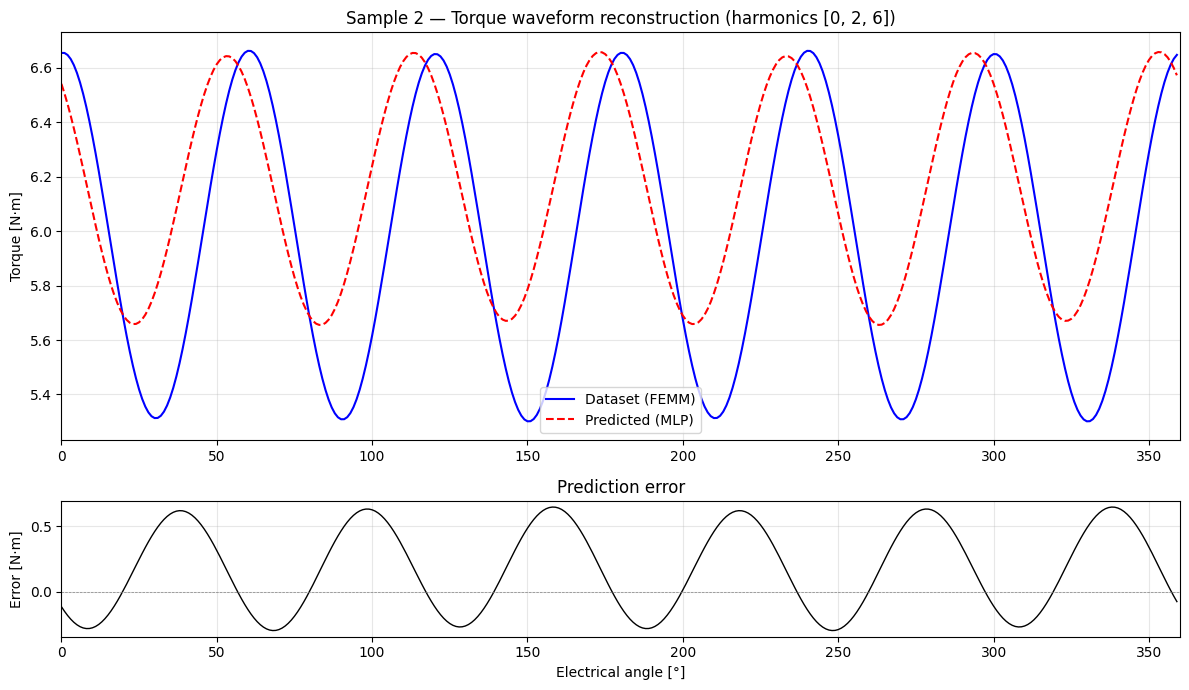

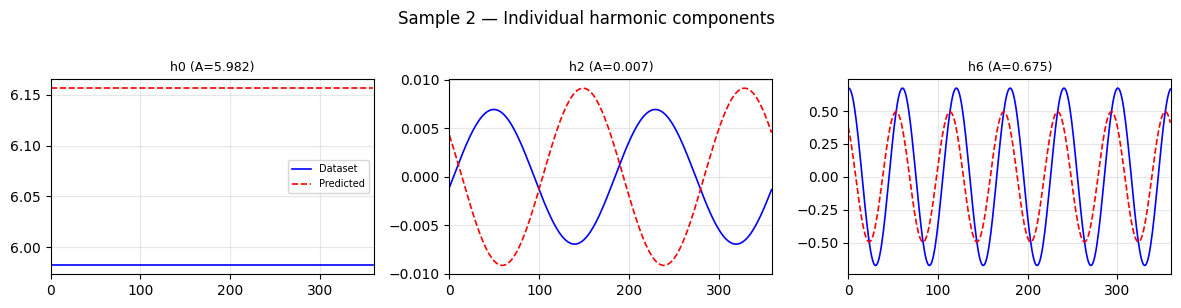

In [15]:
# --- Reconstruct torque waveform from harmonics and compare ---

def reconstruct_waveform(amps, phases_deg, harmonic_indices, n_points=360):
    """
    Reconstruct time-domain waveform from Fourier harmonics.
    
    T(θ) = h0_amp + Σ(k=1..) hk_amp * cos(k*θ + hk_phase_rad)
    
    Parameters
    ----------
    amps              : list of amplitudes (one per selected harmonic)
    phases_deg        : list of phases in degrees (one per selected harmonic)
    harmonic_indices  : list of harmonic orders (e.g. [0, 2, 6])
    n_points          : number of points for reconstruction
    """
    theta_deg = np.linspace(0, 360, n_points, endpoint=False)
    theta_rad = np.deg2rad(theta_deg)
    torque = np.zeros(n_points)
    for i, k in enumerate(harmonic_indices):
        if k == 0:
            torque += amps[i]
        else:
            torque += amps[i] * np.cos(k * theta_rad + np.deg2rad(phases_deg[i]))
    return theta_deg, torque


# Extract harmonics from dataset and prediction (phases from original CSV columns)
amps_actual  = [float(test_row[f'h{h}_amp'])   for h in SELECTED_HARMONICS]
phase_actual = [float(test_row[f'h{h}_phase']) for h in SELECTED_HARMONICS]
amps_pred    = [pred[f'h{h}_amp']     for h in SELECTED_HARMONICS]
phase_pred   = [pred[f'h{h}_phase']   for h in SELECTED_HARMONICS]

theta, T_actual = reconstruct_waveform(amps_actual, phase_actual, SELECTED_HARMONICS)
theta, T_pred   = reconstruct_waveform(amps_pred,   phase_pred,   SELECTED_HARMONICS)

# --- Plot comparison ---
fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(theta, T_actual, 'b-',  lw=1.5, label='Dataset (FEMM)')
ax.plot(theta, T_pred,   'r--', lw=1.5, label='Predicted (MLP)')
ax.set_ylabel('Torque [N·m]')
ax.set_title(f'Sample {sid} — Torque waveform reconstruction (harmonics {SELECTED_HARMONICS})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 360)

ax = axes[1]
ax.plot(theta, T_pred - T_actual, 'k-', lw=1)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('Electrical angle [°]')
ax.set_ylabel('Error [N·m]')
ax.set_title('Prediction error')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 360)

plt.tight_layout()
plt.show()

# --- Also plot individual harmonic contributions ---
n_cols = min(N_HARMONICS, 5)
n_rows = math.ceil(N_HARMONICS / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, squeeze=False)
axes_flat = axes.flatten()

theta_rad = np.deg2rad(theta)
for i, k in enumerate(SELECTED_HARMONICS):
    ax = axes_flat[i]
    if k == 0:
        comp_actual = np.full_like(theta, amps_actual[i])
        comp_pred   = np.full_like(theta, amps_pred[i])
    else:
        comp_actual = amps_actual[i] * np.cos(k * theta_rad + np.deg2rad(phase_actual[i]))
        comp_pred   = amps_pred[i]   * np.cos(k * theta_rad + np.deg2rad(phase_pred[i]))
    
    ax.plot(theta, comp_actual, 'b-',  lw=1.2, label='Dataset')
    ax.plot(theta, comp_pred,   'r--', lw=1.2, label='Predicted')
    ax.set_title(f'h{k} (A={amps_actual[i]:.3f})', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 360)
    if i == 0:
        ax.legend(fontsize=7)
for j in range(N_HARMONICS, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f'Sample {sid} — Individual harmonic components', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 9) FEMM vs Surrogate — Live comparison

Enter new design parameters (b, x, outer_radius).  
The cell will:
1. Build the motor analytically (→ phase_current, torque)
2. Generate the FEMM model and sweep one electrical cycle
3. Predict harmonics with the trained surrogate (using analytical torque as 5th input)
4. Compare torque waveforms side by side



  Design:  b=0.5500   x=0.5000   R=60.00 mm
  Phase current (analytical): 377.66 A
  Analytical torque: 4.8838 N·m
  Pole pairs: 12

Building motor geometry in FEMM...
Finding optimal iq angle...
  Optimal iq angle: -0.4167 mech deg  (torque = 3.7064 N·m)
Running torque sweep (72 steps over 360° elec)...
  Analytical cogging torque (Zhu-Howe): 0.039121 N·m

────────────────────────────────────────────────────────────
                                       FEMM    Surrogate      Error
────────────────────────────────────────────────────────────
             Mean torque [N·m]       3.7119       4.4999    +21.23%
             Torque ripple [%]        40.01        16.20    -59.50%
────────────────────────────────────────────────────────────

                    Harmonic comparison                     
────────────────────────────────────────────────────────────
        Amp FEMM   Amp Surr   Pha FEMM   Pha Surr
────────────────────────────────────────────────────────────
  h0      3.7119  

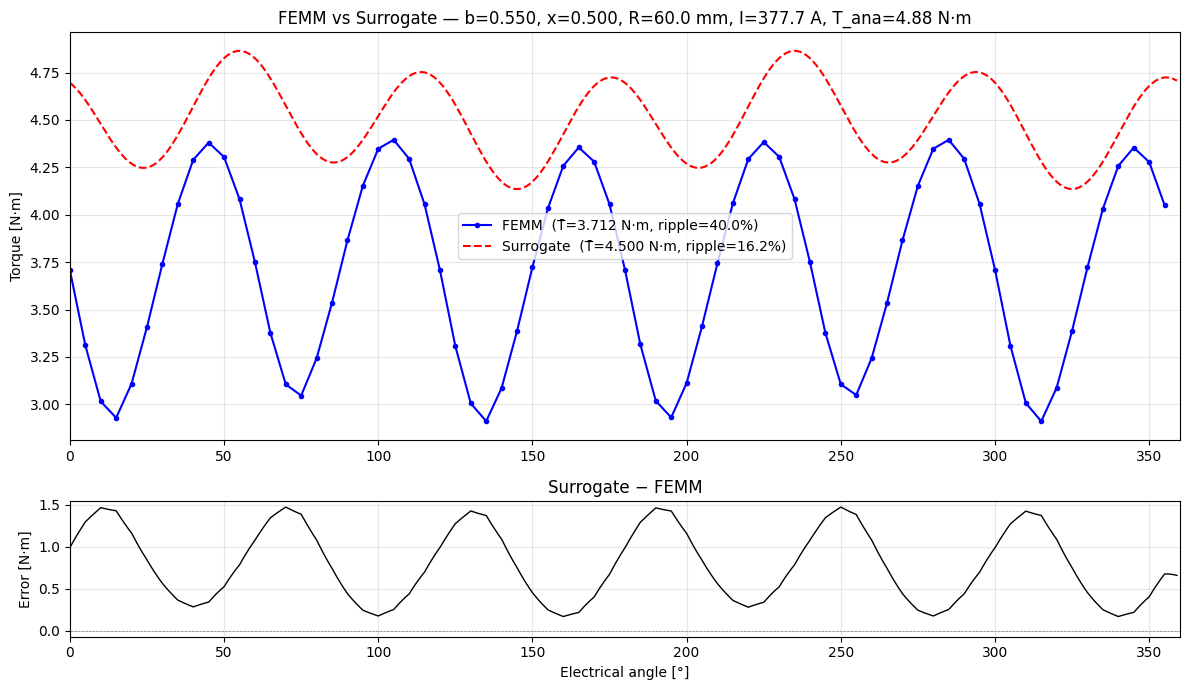

In [16]:
import sys, tempfile, shutil
sys.path.insert(0, r'C:\Proyectos\arfemm\lib\python')
sys.path.insert(0, r'C:\Proyectos\arfemm\lib\examples')
sys.path.insert(0, r'C:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final')

import femm as femmlib
from pmsm import PMSM
from generate_pinn_dataset import create_motor_from_params, DEFAULT_FIXED_PARAMS
from run_sweep import find_iq_angle, sweep_torque, torque_harmonics

# ── User inputs ──────────────────────────────────────────────
b_val  = float(input("b (flux density ratio, e.g. 0.65): "))
x_val  = float(input("x (split ratio, e.g. 0.50): "))
or_val = float(input("outer_radius [m] (e.g. 0.055): "))

# ── 1) Analytical motor design ───────────────────────────────
# Fixed parameters matching the training dataset
params = {
    'b': b_val,
    'x': x_val,
    'outer_radius': or_val,
    'stator_length': 0.02,
    'airgap_thickness': 0.0008,
    'current_density': 10e6,
    'turns': 1,
    'rotation_speed': 3000,
}

fixed_params = DEFAULT_FIXED_PARAMS.copy()
motor = create_motor_from_params(params, fixed_params)
#motor = create_motor_from_params(params)
motor.build()

if motor.error != 0:
    raise ValueError(
        f"Motor design failed (error_code={motor.error}). "
        "Check that b, x, outer_radius are within valid ranges:\n"
        "  b ∈ [0.57, 0.79],  x ∈ [0.35, 0.70],  outer_radius ∈ [0.04, 0.10] m"
    )

phase_current = motor.perf.iabc
torque_analytical = motor.req.torque
pp = motor.spec.pp

print(f"\n{'='*60}")
print(f"  Design:  b={b_val:.4f}   x={x_val:.4f}   R={or_val*1000:.2f} mm")
print(f"  Phase current (analytical): {phase_current:.2f} A")
print(f"  Analytical torque: {torque_analytical:.4f} N·m")
print(f"  Pole pairs: {pp}")
print(f"{'='*60}\n")

# ── 2) Build in FEMM & torque sweep ─────────────────────────
tmp_dir  = tempfile.mkdtemp(prefix="pmsm_compare_")
fem_path = os.path.join(tmp_dir, "test_motor.fem")

try:
    print("Building motor geometry in FEMM...")
    motor.buildInFemm(femm_file=fem_path, current=0.0,
                      copper_temp=70.0, create_mesh=True)
    femmlib.mi_close()

    print("Finding optimal iq angle...")
    iq_angle = find_iq_angle(fem_path, pp, phase_current, n_steps=72)
    #iq_angle = -0.4167

    print("Running torque sweep (72 steps over 360° elec)...")
    waveform = sweep_torque(fem_path, pp, phase_current, iq_angle, n_steps=72)

    femmlib.closefemm()
finally:
    # Clean up temp files
    shutil.rmtree(tmp_dir, ignore_errors=True)

# ── 3) FEMM results ─────────────────────────────────────────
n_fft = max(SELECTED_HARMONICS) + 1
amps_femm_all, phases_femm_all = torque_harmonics(waveform["torque"], n_fft)
amps_femm   = [amps_femm_all[h]   for h in SELECTED_HARMONICS]
phases_femm = [phases_femm_all[h]  for h in SELECTED_HARMONICS]

T_arr_femm   = np.array(waveform["torque"])
theta_femm   = np.array(waveform["theta_e_deg"])
T_mean_femm  = amps_femm_all[0]
T_ripple_femm = (T_arr_femm.max() - T_arr_femm.min()) / T_mean_femm * 100

# ── 4) Surrogate prediction ─────────────────────────────────
surr_kwargs = dict(
    b=b_val, x=x_val,
    outer_radius=or_val,
    phase_current=phase_current,
    torque=torque_analytical,
)

if USE_COGGING_INPUT:
    from femm_utils import cogging_torque_from_row as _cog_row
    motor_row = {
        'slots': motor.spec.slots,
        'pp': motor.spec.pp,
        'magnet_thickness': motor.spec.magnet.thickness,
        'airgap_thickness': motor.spec.airgap.thickness,
        'airgap_radius': motor.spec.airgap.radius,
        'stator_length': motor.spec.stator.length,
    }
    surr_kwargs['cogging_zhu'] = _cog_row(motor_row)
    print(f"  Analytical cogging torque (Zhu-Howe): {surr_kwargs['cogging_zhu']:.6f} N·m")

pred_new = surrogate_predict(model, norm_X, norm_Y, **surr_kwargs)

amps_surr   = [pred_new[f'h{h}_amp']   for h in SELECTED_HARMONICS]
phases_surr = [pred_new[f'h{h}_phase'] for h in SELECTED_HARMONICS]

theta_surr, T_surr = reconstruct_waveform(amps_surr, phases_surr, SELECTED_HARMONICS)
T_mean_surr   = pred_new.get('torque_mean', amps_surr[0])
T_ripple_surr = ((T_surr.max() - T_surr.min()) / T_mean_surr * 100
                 if T_mean_surr > 0 else float('inf'))

# ── 5) Summary table ────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"{'':>30} {'FEMM':>12} {'Surrogate':>12} {'Error':>10}")
print(f"{'─'*60}")
print(f"{'Mean torque [N·m]':>30} {T_mean_femm:>12.4f} {T_mean_surr:>12.4f} "
      f"{(T_mean_surr - T_mean_femm)/T_mean_femm*100:>+9.2f}%")
print(f"{'Torque ripple [%]':>30} {T_ripple_femm:>12.2f} {T_ripple_surr:>12.2f} "
      f"{(T_ripple_surr - T_ripple_femm)/T_ripple_femm*100:>+9.2f}%")
print(f"{'─'*60}")

# ── 6) Harmonic comparison table ─────────────────────────────
print(f"\n{'Harmonic comparison':^60}")
print(f"{'─'*60}")
print(f"{'':>5} {'Amp FEMM':>10} {'Amp Surr':>10} {'Pha FEMM':>10} {'Pha Surr':>10}")
print(f"{'─'*60}")
for i, h in enumerate(SELECTED_HARMONICS):
    print(f"  h{h:<2} {amps_femm[i]:>10.4f} {amps_surr[i]:>10.4f} "
          f"{phases_femm[i]:>10.2f} {phases_surr[i]:>10.2f}")

# ── 7) Waveform plot ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                         gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(theta_femm, T_arr_femm, 'b-o', lw=1.5, ms=3,
        label=f'FEMM  (T̄={T_mean_femm:.3f} N·m, ripple={T_ripple_femm:.1f}%)')
ax.plot(theta_surr, T_surr, 'r--', lw=1.5,
        label=f'Surrogate  (T̄={T_mean_surr:.3f} N·m, ripple={T_ripple_surr:.1f}%)')
ax.set_ylabel('Torque [N·m]')
ax.set_title(f'FEMM vs Surrogate — b={b_val:.3f}, x={x_val:.3f}, '
             f'R={or_val*1000:.1f} mm, I={phase_current:.1f} A, T_ana={torque_analytical:.2f} N·m')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 360)

# Error subplot (interpolate FEMM to surrogate grid)
T_femm_interp = np.interp(theta_surr, theta_femm, T_arr_femm)
ax = axes[1]
ax.plot(theta_surr, T_surr - T_femm_interp, 'k-', lw=1)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('Electrical angle [°]')
ax.set_ylabel('Error [N·m]')
ax.set_title('Surrogate − FEMM')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 360)

plt.tight_layout()
plt.show()
